## Teledyne FLIR Boson+
This notebook utilizes and expands on the functions and equations given by the "PythonSimulation.ipynb" notebook to determine the validity of the Teledyne FLIR Boson+ Bolometer for the SeeSat e.V. ERWIN mission.

## Spectral Radiance / Planck's Law
$$ S(\lambda, T) = \frac{2 h c^2}{\lambda^5} \cdot \frac{1}{\exp\left(\tfrac{h c}{\lambda k T}\right) - 1} $$

- $S(\lambda, T)$: Spectral Radiance
- $h$: Planck constant,
- $c$: speed of light,
- $k$: Boltzmann constant,
- $T$: temperature (K),
- $\lambda$: wavelength (m)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import h, c, k, pi

def planck_lambda(lmbd, T):
    """
    Planck's law: spectral radiance per wavelength [W / (m^3 sr)]
    lmbd: wavelength in m
    T: temperature in K
    
    Uses np.expm1 for better numerical stability without clipping.
    """
    x = (h * c) / (lmbd * k * T)
    return (2 * h * c**2 / lmbd**5) / np.expm1(x)

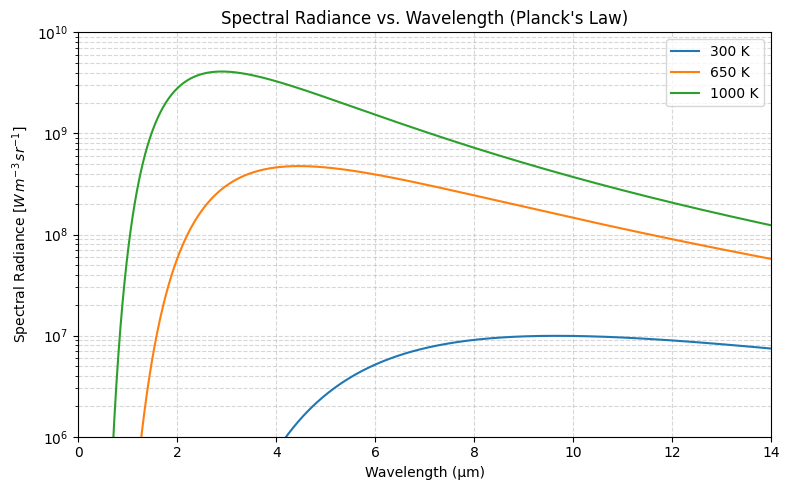

In [2]:
# Wavelengths from 0.1 to 14 micrometers, avoid zero to prevent division by zero, in meters
wavelength_um = np.linspace(0.1, 14, 1000)
wavelength_m = wavelength_um * 1e-6

temperatures = [300, 650, 1000]
labels = ["300 K", "650 K", "1000 K"]

plt.figure(figsize=(8, 5))
for T, label in zip(temperatures, labels):
    radiance = planck_lambda(wavelength_m, T)
    plt.plot(wavelength_um, radiance, label=label)

plt.xlabel("Wavelength (μm)")
plt.ylabel(r"Spectral Radiance $[W\,m^{-3}\,sr^{-1}]$")
plt.title("Spectral Radiance vs. Wavelength (Planck's Law)")
plt.yscale('log')
plt.ylim(1e6, 1e10)
plt.legend()
plt.xlim(0, 14)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
plt.show()

## Atmospheric Transmission / MODTRAN simulation
Using MODTRAN, the atmospheric transmission for a range of wavelengths can be determined

In [3]:
import pandas as pd

def get_modtran_data(file_path):
    """
    Load MODTRAN simulation data from a CSV file.
    
    Parameters:
    - file_path: Path to the CSV file containing MODTRAN data.
    
    Returns:
    - DataFrame with columns 'Wavelength' and 'Transmission'.
    """
    df = pd.read_csv(file_path, header=4)
    df.set_index('Freq', inplace=True)
    df = df.iloc[1:-1]
    df.index = 1e-2 / df.index.astype(float)
    df.index.name = 'Wavelength [m]'
    df.columns = df.columns.str.strip()
    df['combin'] = pd.to_numeric(df['combin'], errors='coerce')
    tau = df['combin'].values
    wavelength = df.index.values
    sort_idx = np.argsort(wavelength)
    wavelength = wavelength[sort_idx]
    tau = tau[sort_idx]
    return wavelength, tau, df

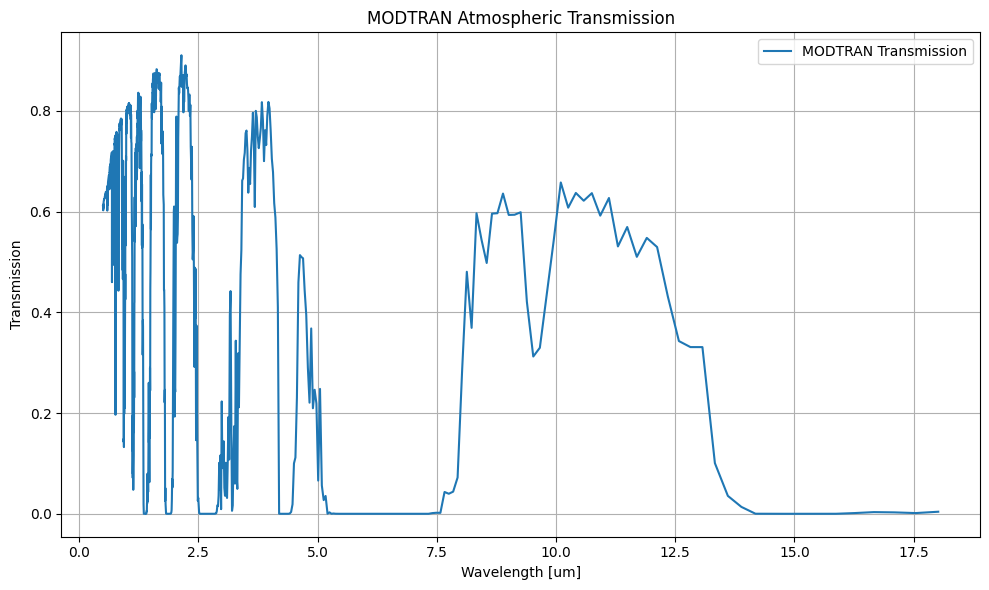

In [ ]:
wavelength, transmittance, _ =  get_modtran_data('./AngstromLaw2.csv')
wavelength = wavelength/1e-6
plt.figure(figsize=(10, 6))
plt.plot(wavelength, transmittance, label='MODTRAN Transmission', color='tab:blue')
plt.xlabel('Wavelength [μm]')
plt.ylabel('Transmission')
plt.title('MODTRAN Atmospheric Transmission')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Imager Specification
**Teledyne FLIR Boson+**
| Param                | Value         | Description                       |
|----------------------|------------------------|------------------------------------|
| **Wavelength-Range** | 8–14 µm                | LWIR-Spectral-Range               |
| **NETD**             | 40 mK, 50 mK, 60 mK     | Detector-Noise, depends on the imager variant|
| **HFOV**              | 34° | Field of View; Only for Testing         |
| **Pixel Pitch**      | 12 µm                   | Detector-Pixel-Size                |
| **Optical Transmission** | τ<sub>opt</sub> = 0.9 | Transmission of the Optic             |
| **Pixel Count** | 320x256 / 640x512 | Number of Pixels in the matrix             |
| **IFOV (mrad)** | 1.9047619047619 | Instantaneous FoV; What a single pixel sees|

**Mission Environment (Different Optic)**

When two numbers - Pixel count: left for 320x256 / right for 640x512 
| Param                | Value         | Description                       |
|----------------------|------------------------|------------------------------------|
| **HFOV**      | 6° / 12° | Field of View; depends on the used Optic and Pixel Count|
| **GSD**       | 197m | Ground Sampling Distance for a single Pixel|
| **Swath width**       | 62889m / 126125m | How much the whole imager sees on the ground|
| **Distance**       | 600km | Satellite Height|